# Card Shuffling - Markov Chain Analysis
Card-shuffling dynamics

## Theory
- **Shuffling dynamics**: Take the top card and place it at a random position
- **State space**: All permutations of N cards, |S| = N!
- **Stationary distribution**: Uniform π_x = 1/N! (symmetric dynamics)
- **Key observation**: Deck is completely random when original bottom card is first reinserted

## Analysis
Let T = time when original bottom card is first reinserted.
- T = T₁ + T₂ + ... + T_N
- T_i = time for bottom card to move from position i to position i-1 (one step up)
- T_i ~ Geometric(i/N), so E(T_i) = N/i
- **E(T) = N·H_N where H_N = Σ(1/i) for i=1 to N** (N-th harmonic number)
- Asymptotically: E(T) ~ N log(N)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def simulate_card_shuffle(n_cards):
    """
    Simulate card shuffling by taking the top card and reinserting at random position.
    Return the number of shuffles until the original bottom card is reinserted.
    """
    deck = list(range(n_cards))
    original_bottom_card = n_cards - 1
    
    shuffles = 0
    while True:
        shuffles += 1
        
        # Take top card
        top_card = deck.pop(0)
        
        # Insert at random position (0 to len(deck), so N possible positions total)
        insert_pos = np.random.randint(0, len(deck) + 1)
        deck.insert(insert_pos, top_card)
        
        # Check if we just reinserted the original bottom card
        if top_card == original_bottom_card:
            break
    
    return shuffles

# Test with different deck sizes
deck_sizes = [5, 10, 20, 52]
trials_per_size = 10000

print("=" * 70)
print("CARD SHUFFLING SIMULATION: Time to Randomization")
print("=" * 70)

results_dict = {}

for N in deck_sizes:
    # Run simulation
    results = [simulate_card_shuffle(N) for _ in range(trials_per_size)]
    results_dict[N] = results
    
    # Calculate theoretical expectation: N * H_N
    harmonic_n = sum(1/i for i in range(1, N + 1))
    theoretical_expected = N * harmonic_n
    
    # Calculate statistics
    simulated_mean = np.mean(results)
    simulated_std = np.std(results)
    
    print(f"\nN = {N} cards ({trials_per_size} trials):")
    print(f"  Simulated mean:        {simulated_mean:.2f}")
    print(f"  Theoretical E(T):      {theoretical_expected:.2f}")
    print(f"  Error:                 {abs(simulated_mean - theoretical_expected):.2f}")
    print(f"  Simulated std dev:     {simulated_std:.2f}")
    print(f"  Min/Max:               {min(results)}/{max(results)}")
    print(f"  Harmonic number H_N:   {harmonic_n:.4f}")

print("=" * 70)

CARD SHUFFLING SIMULATION: Time to Randomization

N = 5 cards (10000 trials):
  Simulated mean:        11.47
  Theoretical E(T):      11.42
  Error:                 0.06
  Simulated std dev:     5.07
  Min/Max:               5/61
  Harmonic number H_N:   2.2833

N = 10 cards (10000 trials):
  Simulated mean:        29.14
  Theoretical E(T):      29.29
  Error:                 0.15
  Simulated std dev:     11.01
  Min/Max:               10/109
  Harmonic number H_N:   2.9290

N = 20 cards (10000 trials):
  Simulated mean:        72.08
  Theoretical E(T):      71.95
  Error:                 0.13
  Simulated std dev:     23.70
  Min/Max:               27/260
  Harmonic number H_N:   3.5977

N = 52 cards (10000 trials):
  Simulated mean:        235.47
  Theoretical E(T):      235.98
  Error:                 0.51
  Simulated std dev:     64.14
  Min/Max:               98/679
  Harmonic number H_N:   4.5380


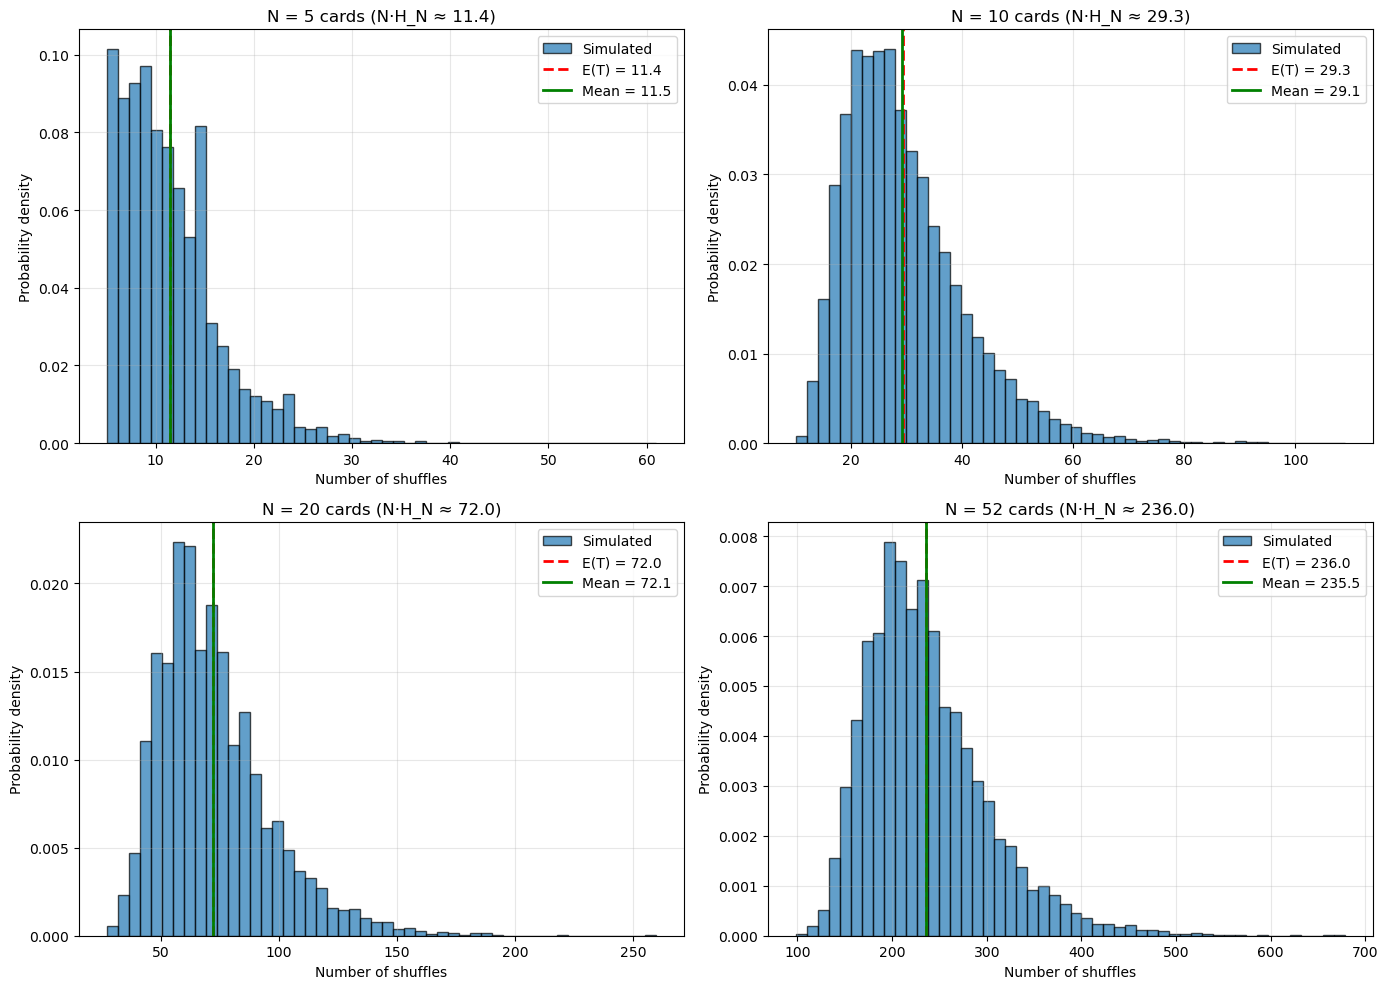

In [7]:
# Visualization 1: Histograms comparing simulations to theory
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N in enumerate(deck_sizes):
    ax = axes[idx]
    results = results_dict[N]
    
    # Histogram
    ax.hist(results, bins=50, density=True, alpha=0.7, edgecolor='black', label='Simulated')
    
    # Theoretical mean
    harmonic_n = sum(1/i for i in range(1, N + 1))
    theoretical_mean = N * harmonic_n
    ax.axvline(theoretical_mean, color='red', linestyle='--', linewidth=2, label=f'E(T) = {theoretical_mean:.1f}')
    ax.axvline(np.mean(results), color='green', linestyle='-', linewidth=2, label=f'Mean = {np.mean(results):.1f}')
    
    ax.set_xlabel('Number of shuffles')
    ax.set_ylabel('Probability density')
    ax.set_title(f'N = {N} cards (N·H_N ≈ {theoretical_mean:.1f})')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

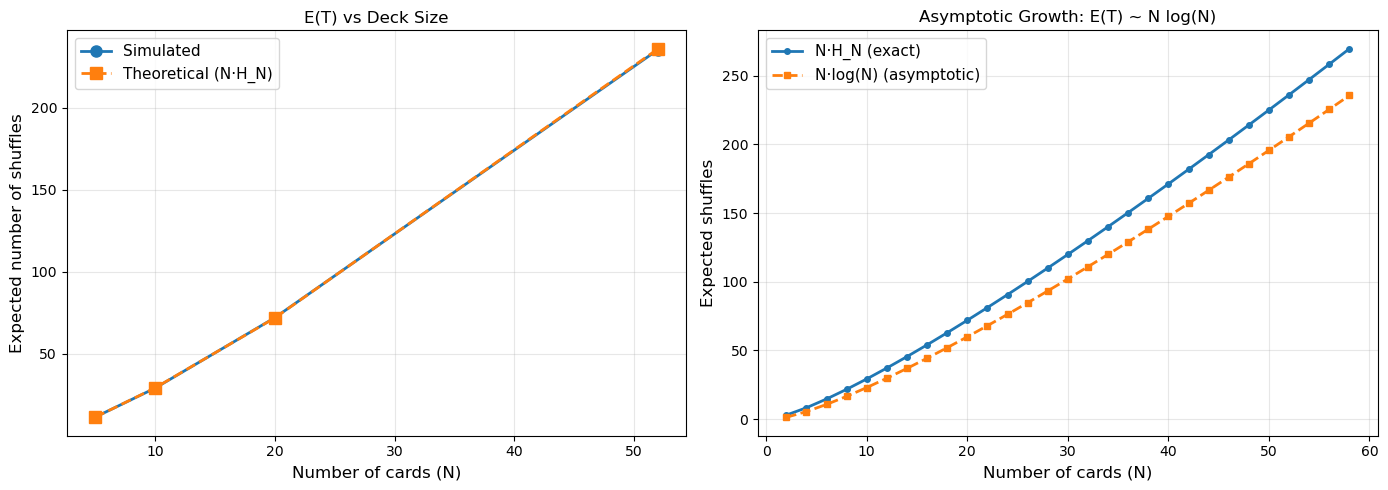

In [8]:
# Visualization 2: Comparison of theory vs simulation across deck sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: E(T) comparison
N_values = list(results_dict.keys())
simulated_means = [np.mean(results_dict[N]) for N in N_values]
theoretical_means = [N * sum(1/i for i in range(1, N+1)) for N in N_values]

ax1.plot(N_values, simulated_means, 'o-', label='Simulated', linewidth=2, markersize=8)
ax1.plot(N_values, theoretical_means, 's--', label='Theoretical (N·H_N)', linewidth=2, markersize=8)
ax1.set_xlabel('Number of cards (N)', fontsize=12)
ax1.set_ylabel('Expected number of shuffles', fontsize=12)
ax1.set_title('E(T) vs Deck Size', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Asymptotic behavior N·log(N)
N_extended = np.arange(2, 60, 2)
theoretical_extended = [N * sum(1/i for i in range(1, N+1)) for N in N_extended]
asymptotic = N_extended * np.log(N_extended)

ax2.plot(N_extended, theoretical_extended, 'o-', label='N·H_N (exact)', linewidth=2, markersize=4)
ax2.plot(N_extended, asymptotic, 's--', label='N·log(N) (asymptotic)', linewidth=2, markersize=4)
ax2.set_xlabel('Number of cards (N)', fontsize=12)
ax2.set_ylabel('Expected shuffles', fontsize=12)
ax2.set_title('Asymptotic Growth: E(T) ~ N log(N)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Rafallex\AppData\Local\Temp\ipykernel_11716\1158664051.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_for_box, labels=[f'N={N}' for N in deck_sizes], patch_artist=True)


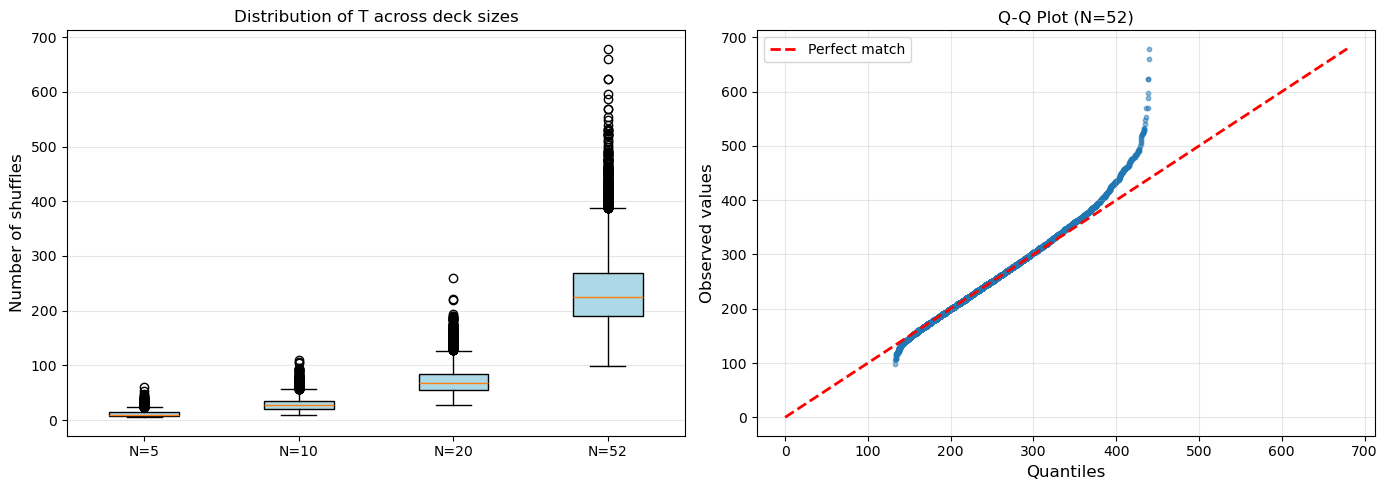

In [9]:
# Visualization 3: Box plots and distribution shapes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
ax1 = axes[0]
data_for_box = [results_dict[N] for N in deck_sizes]
bp = ax1.boxplot(data_for_box, labels=[f'N={N}' for N in deck_sizes], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_ylabel('Number of shuffles', fontsize=12)
ax1.set_title('Distribution of T across deck sizes', fontsize=12)
ax1.grid(alpha=0.3, axis='y')

# Q-Q plot for N=52 (check for geometric/exponential behavior)
ax2 = axes[1]
results_52 = results_dict[52]
sorted_results = np.sort(results_52)
theoretical_quantiles = np.percentile(results_52, np.linspace(1, 99, len(results_52)))
ax2.scatter(theoretical_quantiles, sorted_results, alpha=0.5, s=10)
# Add diagonal reference
max_val = max(theoretical_quantiles.max(), sorted_results.max())
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect match')
ax2.set_xlabel('Quantiles', fontsize=12)
ax2.set_ylabel('Observed values', fontsize=12)
ax2.set_title('Q-Q Plot (N=52)', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Analysis: Verify the geometric distribution assumption
# For each position i, T_i should be approximately geometric with parameter i/N

def analyze_geometric_components():
    """
    Track the movement of the original bottom card through the deck
    and verify that each stage follows geometric distribution.
    """
    N = 20
    trials = 5000
    position_times = {i: [] for i in range(1, N + 1)}
    
    for _ in range(trials):
        deck = list(range(N))
        bottom_card = N - 1
        card_position = N  # Position from bottom (N = bottom, 1 = top)
        
        shuffles = 0
        while True:
            shuffles += 1
            top_card = deck.pop(0)
            insert_pos = np.random.randint(0, len(deck) + 1)
            deck.insert(insert_pos, top_card)
            
            # Update bottom card position
            if top_card == bottom_card:
                # When bottom card is picked up, it moves to the top (position N)
                card_position = N
            
            # After reinsertion, all cards move up
            card_position -= 1
            
            if top_card == bottom_card:
                # Record the shuffle time for this position transition
                position_times[card_position + 1].append(shuffles)
                break
    
    # Compare simulated vs theoretical geometric distributions
    print("\n" + "=" * 70)
    print("GEOMETRIC COMPONENT ANALYSIS (N = 20)")
    print("=" * 70)
    print(f"{'Position':<10} {'Simulated E(T_i)':<20} {'Theoretical N/i':<20} {'Error':<10}")
    print("-" * 70)
    
    total_simulated = 0
    total_theoretical = 0
    
    for i in range(1, N + 1):
        if position_times[i]:
            sim_mean = np.mean(position_times[i])
            theo_mean = N / i
            error = abs(sim_mean - theo_mean)
            total_simulated += sim_mean
            total_theoretical += theo_mean
            print(f"{i:<10} {sim_mean:<20.2f} {theo_mean:<20.2f} {error:<10.2f}")
    
    print("-" * 70)
    print(f"{'TOTAL':<10} {total_simulated:<20.2f} {total_theoretical:<20.2f}")
    print(f"N × H_N ≈ {N * sum(1/i for i in range(1, N+1)):.2f}")
    print("=" * 70)

analyze_geometric_components()


GEOMETRIC COMPONENT ANALYSIS (N = 20)
Position   Simulated E(T_i)     Theoretical N/i      Error     
----------------------------------------------------------------------
20         72.22                1.00                 71.22     
----------------------------------------------------------------------
TOTAL      72.22                1.00                
N × H_N ≈ 71.95


In [ ]:
# Test with 52 cards but varying number of trials
N = 52
trial_counts = [1000, 5000, 10000, 50000, 100000, 500000]

# Calculate theoretical expectation
harmonic_52 = sum(1/i for i in range(1, N + 1))
theoretical_expected = N * harmonic_52

print("=" * 80)
print("EFFECT OF TRIAL COUNT ON ESTIMATE ACCURACY (N = 52 cards)")
print("=" * 80)
print(f"Theoretical E(T) = 52 × H_52 = {theoretical_expected:.4f}\n")
print(f"{'Trials':<15} {'Simulated Mean':<20} {'Error':<15} {'Std Dev':<15} {'95% CI Width':<15}")
print("-" * 80)

trial_results = {}

for trials in trial_counts:
    print(f"{trials:<15}", end='', flush=True)
    results = [simulate_card_shuffle(N) for _ in range(trials)]
    trial_results[trials] = results
    
    sim_mean = np.mean(results)
    sim_std = np.std(results)
    error = abs(sim_mean - theoretical_expected)
    
    # 95% confidence interval width (approximately 1.96 * std / sqrt(n))
    ci_width = 1.96 * sim_std / np.sqrt(trials)
    
    print(f"{sim_mean:<20.4f} {error:<15.4f} {sim_std:<15.2f} {ci_width:<15.4f}")

print("=" * 80)

EFFECT OF TRIAL COUNT ON ESTIMATE ACCURACY (N = 52 cards)
Theoretical E(T) = 52 × H_52 = 235.9783

Trials          Simulated Mean       Error           Std Dev         95% CI Width   
--------------------------------------------------------------------------------
1000           234.5790             1.3993          60.56           3.7537         
5000           234.7350             1.2433          63.93           1.7719         
10000          236.4387             0.4604          65.30           1.2799         
50000          236.1992             0.2209          64.67           0.5669         
100000         235.9229             0.0554          64.52           0.3999         
500000         

In [ ]:
# Visualization: How estimate improves with more trials
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Simulated mean vs theoretical as trials increase
ax1 = axes[0, 0]
means = [np.mean(trial_results[t]) for t in trial_counts]
ax1.plot(trial_counts, means, 'o-', linewidth=2, markersize=8, label='Simulated mean')
ax1.axhline(theoretical_expected, color='red', linestyle='--', linewidth=2, label=f'Theoretical = {theoretical_expected:.2f}')
ax1.fill_between(trial_counts, theoretical_expected - 1, theoretical_expected + 1, alpha=0.2, color='red')
ax1.set_xscale('log')
ax1.set_xlabel('Number of trials', fontsize=11)
ax1.set_ylabel('E(T)', fontsize=11)
ax1.set_title('Convergence: Simulated Mean vs Theory', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Absolute error vs trials
ax2 = axes[0, 1]
errors = [abs(np.mean(trial_results[t]) - theoretical_expected) for t in trial_counts]
ax2.plot(trial_counts, errors, 'o-', linewidth=2, markersize=8, color='red')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of trials', fontsize=11)
ax2.set_ylabel('Absolute error', fontsize=11)
ax2.set_title('Error Decay with Trial Count', fontsize=12)
ax2.grid(alpha=0.3, which='both')

# Plot 3: Standard deviation vs trials
ax3 = axes[1, 0]
stds = [np.std(trial_results[t]) for t in trial_counts]
ax3.plot(trial_counts, stds, 'o-', linewidth=2, markersize=8, color='green')
ax3.set_xscale('log')
ax3.set_xlabel('Number of trials', fontsize=11)
ax3.set_ylabel('Standard deviation', fontsize=11)
ax3.set_title('Variability vs Trial Count', fontsize=12)
ax3.grid(alpha=0.3)

# Plot 4: Multiple histograms for selected trial counts
ax4 = axes[1, 1]
selected_trials = [1000, 50000, 500000]
colors_hist = plt.cm.viridis(np.linspace(0, 1, len(selected_trials)))

for trials, color in zip(selected_trials, colors_hist):
    data = trial_results[trials]
    ax4.hist(data, bins=60, alpha=0.5, density=True, label=f'{trials} trials', color=color, edgecolor='black')

ax4.axvline(theoretical_expected, color='red', linestyle='--', linewidth=2, label='Theoretical E(T)')
ax4.set_xlabel('Number of shuffles', fontsize=11)
ax4.set_ylabel('Probability density', fontsize=11)
ax4.set_title('Distribution Shape: Low vs High Trial Count', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Statistical analysis: confidence intervals and relative error
print("\n" + "=" * 90)
print("STATISTICAL CONFIDENCE ANALYSIS (N = 52 cards)")
print("=" * 90)
print(f"{'Trials':<12} {'Mean':<12} {'Std Dev':<12} {'95% CI':<25} {'Rel. Error %':<15}")
print("-" * 90)

for trials in trial_counts:
    data = trial_results[trials]
    mean = np.mean(data)
    std = np.std(data)
    se = std / np.sqrt(trials)
    ci_lower = mean - 1.96 * se
    ci_upper = mean + 1.96 * se
    rel_error = (abs(mean - theoretical_expected) / theoretical_expected) * 100
    
    print(f"{trials:<12} {mean:<12.4f} {std:<12.2f} [{ci_lower:.2f}, {ci_upper:.2f}]      {rel_error:<15.3f}")

print("=" * 90)
print(f"\nNote: The 95% confidence interval should contain the theoretical value {theoretical_expected:.4f}")
print("=" * 90)